In [ ]:
import sys
from pathlib import Path
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root

s = Simulation()
N_t = 4000
tg = 200
tlist = np.linspace(0, tg, N_t)

In [2]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg):
    args = [None] * 5
    amp, wd = compute_cos_params(s, tg)
    # with the right amplitude for the given gate time, we can compute parameters from heff
    heff_params = s.heff(wd, amp)
    Delta = heff_params[2][2] - heff_params[0][0]
    # rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
    rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case
    # with all parameters set we can compute the target hamiltonian
    ht, ht_args = h_target(Delta, rrr, tg)
    wd0 = s.find_resonance(0)
    args[0] = ht_args
    args[2] = s.heff(wd0, 0)
    args[3] = wd0
    args[4] = amp
    return ht, args
ht, args = compute_htarget(200)
_, _, heff0, wd, amp = args

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


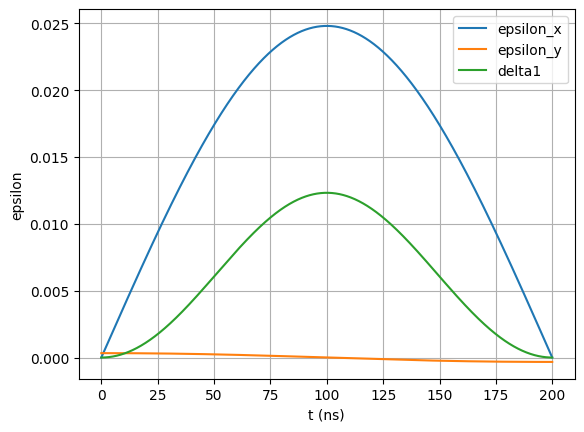

3.0e-05


In [3]:


ex = np.array([args[0][0](t) for t in tlist])
ey = np.array([args[0][1](t) for t in tlist])
d1 = np.array([abs(args[0][2](t)) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()
# target hamiltonian- fidelity
fid_t = extract_pop_fid(ht, tlist)['iswap_fidelity']
print(f"{(1-fid_t):.1e}")

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

100%|██████████| 2/2 [00:05<00:00,  2.52s/it]


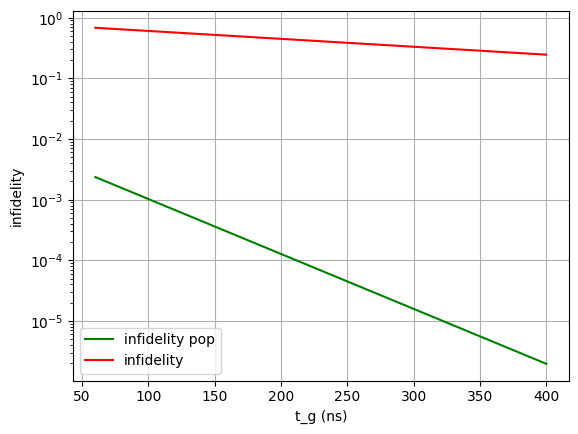

In [17]:
def plot_tg_fid_curve(hamiltonian_function, n, tg_min = 60, tg_max = 400):
    lf_pop = []
    lf = []
    ltg = np.linspace(tg_min, tg_max, n)
    for tg in tqdm(ltg):
        h, _ = hamiltonian_function(tg)
        tlist = np.linspace(0, tg, N_t)
        f = extract_fidelity(h, tlist)
        fpop = extract_pop_fid(h, tlist)['iswap_fidelity']
        lf_pop.append(1-fpop)
        lf.append(1-f)
    ax = plt.subplot()
    plt.plot(ltg, lf_pop, label='infidelity pop', color='green')
    plt.plot(ltg, lf, label='infidelity', color='red')
    plt.xlabel('t_g (ns)')
    plt.ylabel('infidelity')
    ax.set_yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_tg_fid_curve(compute_htarget, 2)

After verifying the fidelity of the target-hamiltonian, now the target hamiltonian must be achieved by a given time-dependant pulse-shape that is applied to the coupler

In [18]:
import pickle
from pathlib import Path

# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi]
amp_real_range = (0, 0.6 * 2*np.pi)
amp_imag_range = (0, 0.6 * 2*np.pi)

# Load coefficients if they exist
if coeff_file.exists():
    with open(coeff_file, 'rb') as f:
        coefficients_data = pickle.load(f)
    coeffs01 = coefficients_data['coeffs01']
    coeffs00 = coefficients_data['coeffs00']
    coeffs11 = coefficients_data['coeffs11']
    coeffs22 = coefficients_data['coeffs22']
    print(f"Coefficients loaded from {coeff_file}")
else:
    N = 20
    coeffs01 = fit_heff_element(s, 0, 1, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs00 = fit_heff_element(s, 0, 0, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs11 = fit_heff_element(s, 1, 1, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs22 = fit_heff_element(s, 2, 2, wd_range, amp_real_range, amp_imag_range, N,N,N)
    # Save coefficients
    coefficients_data = {
        'coeffs01': coeffs01,
        'coeffs00': coeffs00,
        'coeffs11': coeffs11,
        'coeffs22': coeffs22
    }
    with open(coeff_file, 'wb') as f:
        pickle.dump(coefficients_data, f)
        print(f"Coefficients saved to {coeff_file}")


Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [19]:
from scipy.optimize import root
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = np.array([1, wd, ar, ai, wd**2, ar**2, ai**2,
                  wd*ar, wd*ai, ar*ai])
    return x @ coeffs

def find_parameter_change_fit(wd0, heff0, heff_t):
    dd_target = (heff_t[0,0] - heff_t[1,1]) - (heff0[0,0] - heff0[1,1])
    
    dd2_target = (heff_t[0][0] + (heff_t[1,1] - heff_t[0,0])/2 - heff_t[2,2]) - (heff0[0][0] + (heff0[1,1] - heff0[0,0])/2 - heff0[2,2])
    omega_target = heff_t[0,1] - heff0[0,1]
    dwd_range = (-1,1)
    da_range = amp_real_range
    def objective(trial):
        dw = trial.suggest_float("dw", *dwd_range)
        ar = trial.suggest_float("dar", *da_range)
        ai = trial.suggest_float("dai", *da_range)
        wd = wd0 + dw
        amp = ar + 1j*ai

        dd = (heff_fit(coeffs00, wd, amp)
              - heff_fit(coeffs11, wd, amp)
              - (heff_fit(coeffs00, wd0, 0)
                 - heff_fit(coeffs11, wd0, 0)))
        dd2 = (heff_fit(coeffs00, wd, amp)
              - heff_fit(coeffs11, wd, amp)
              - (heff_fit(coeffs00, wd0, 0)
                 - heff_fit(coeffs11, wd0, 0)))
        omega = (heff_fit(coeffs01, wd, amp)
                 - heff_fit(coeffs01, wd0, 0))
        residual = [abs(np.real(dd - dd_target)),
                abs(np.real(dd2 - dd2_target)),
                abs(np.real(omega - omega_target)),
                abs(np.imag(omega - omega_target))]
        residual = [residual[0],0,residual[2],residual[3]]
        weights = np.array([1,0,1,0.5])
        err = np.sum(weights * np.abs(residual)**2)
        return err

    sampler = optuna.samplers.CmaEsSampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=1000)
    return study.best_params
    
# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

setup the heff_modulated method and test hamiltonian compliance with one example

In [20]:
ht, args = compute_htarget(tg)
ht_func = sum_list(ht)
_, _, heff0, wd0, amp = args
def heff_modulated(t, args=None, dw = None, da = None):
    if not dw or not da: 
        res = find_parameter_change_fit(wd0, heff0, ht_func(t))
        dw = res['dw']
        da = res['dar'] + 1j*res['dai']
    return Qobj(s.heff(wd0 + dw.real, da))
    
# for some examples, show if the hamiltonian comes close to the target
tt = 115
print("h0: ")
display(Qobj(heff0))
print("heff_modulated: ")
display(heff_modulated(tt))
print("htarget: ")
display(sum_list(ht)(tt))

h0: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.         -1.17369658]]

heff_modulated: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.06787122e-03+0.00000000e+00j  1.21814280e-02-7.67015727e-05j
  -7.25570598e-03+9.13761709e-05j]
 [ 1.21814280e-02+7.67015727e-05j -1.27006260e-02+0.00000000e+00j
   1.20900215e-01-7.61260221e-04j]
 [-7.25570598e-03-9.13761709e-05j  1.20900215e-01+7.61260221e-04j
  -1.19241991e+00+0.00000000e+00j]]

htarget: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.        +0.00000000e+00j  0.01205345+4.01639888e-05j
   0.        +0.00000000e+00j]
 [ 0.01205345-4.01639888e-05j -0.01163526+0.00000000e+00j
   0.11886564+3.96078992e-04j]
 [ 0.        +0.00000000e+00j  0.11886564-3.96078992e-04j
  -1.16438255+0.00000000e+00j]]

drive_signal_func gives the time dependant DRAG amplitude 

In [21]:
def drive_signal_func(t, args=None, dw=None, da=None):
    def pulse_params(t, dw=None, da=None):
        if not dw or not da:
            res = find_parameter_change_fit(wd0, heff0, ht_func(t))
            dw = res['dw']
            da = res['dar'] + 1j*res['dai']
        return wd0 + dw, 0+da
    wd, a = pulse_params(t, dw=dw, da=da)
    return a * np.cos(wd * t)

In [ ]:
# Precomputation of heff_modulated over full tlist with caching
from scipy.interpolate import CubicSpline
import pickle

heff_file = coeff_dir / 'heff_modulated_precomputed.pkl'
drive_signal_precomputed = []

if heff_file.exists():
    with open(heff_file, 'rb') as f:
        heff_precomputed = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
else:
    heff_precomputed = []
    res = find_parameter_change_fit(wd0, heff0, ht_func(tt))
    dw = res['dw']
    da = res['dar'] + 1j*res['dai']
    drive_signal_func(tt, dw=dw, da=da)
    for t in tqdm(tlist):
        res = find_parameter_change_fit(wd0, heff0, ht_func(t))
        dw = res['dw']
        da = res['dar'] + 1j*res['dai']
        drive_signal = drive_signal_func(t, dw=dw, da=da)
        drive_signal_precomputed.append(drive_signal)
        heff_precomputed.append(heff_modulated(t, dw=dw, da=da))
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_precomputed, f)
    print(f"heff_modulated saved to {heff_file}")

def heff_modulated_interp(t, args=None):
    heff_matrix = np.zeros(heff_precomputed[0].shape, dtype=complex)
    if t <= tlist[0]:
        return heff_precomputed[0], args
    if t >= tlist[-1]:
        return heff_precomputed[-1], args
    idx = np.searchsorted(tlist, t) - 1
    alpha = (t - tlist[idx]) / (tlist[idx + 1] - tlist[idx])
    for i in range(0,3):
        for j in range(0,3):
            heff_matrix[i][j] = heff_precomputed[idx][i][j]*(1-alpha) + heff_precomputed[idx+1][i][j]*alpha
    return Qobj(heff_matrix), args

heff_modulated loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_modulated_precomputed.pkl


wth the heff_modulated_interp function, the extraction of fidelity measurements can be done fast. To Test, we redo the plot that was allready done for ht

100%|██████████| 200/200 [00:21<00:00,  9.47it/s]


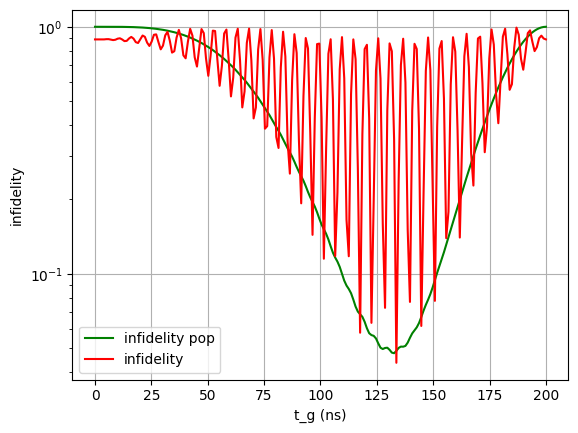

In [32]:
plot_tg_fid_curve(heff_modulated_interp, 200, tg_max=200, tg_min = 0)

In [31]:
# Precompute drive signal with caching
from scipy.interpolate import interp1d
import pickle

drive_file = coeff_dir / 'drive_signal_precomputed.pkl'

if drive_file.exists():
    with open(drive_file, 'rb') as f:
        drive_signal_precomputed = pickle.load(f)
    print(f"drive_signal loaded from {drive_file}")
else:
    if(len(drive_signal_precomputed) == 0):
        drive_signal_precomputed = np.array([drive_signal_func(t) for t in tqdm(tlist)])
    with open(drive_file, 'wb') as f:
        pickle.dump(drive_signal_precomputed, f)
    print(f"drive_signal saved to {drive_file}")

def drive_signal_interp(t, args=None):
    if t <= tlist[0]:
        return drive_signal_precomputed[0]
    if t >= tlist[-1]:
        return drive_signal_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    y0 = drive_signal_precomputed[idx]
    y1 = drive_signal_precomputed[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    # print("idx: ", idx, " t0: ", t0, " t1: ", t1, " y0: ",y0, " y1: ",y1, " alpha: ", alpha)
    return (1 - alpha) * y0 + alpha * y1

drive_signal loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/drive_signal_precomputed.pkl


After computing pulse_shape and heff_modulated for all times of tlist to facilitate computation, the pulse shape can be plotted

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


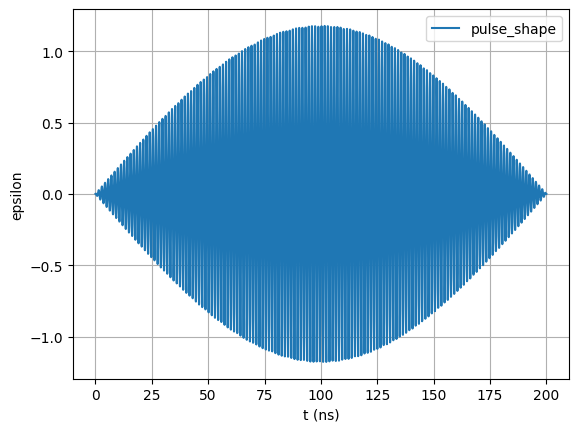

In [25]:
plt.figure()
plt.plot(tlist, drive_signal_precomputed, label='pulse_shape')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# with the precomputed values, now get the fidelity 
# simulate the result directly over H0 and V1 from s 
lh = [s.H0_dressed, [s.V1_dressed, drive_signal_interp]]
f = extract_pop_fid(lh, tlist, plot=True, sim=s)

  0%|          | 0/3 [00:00<?, ?it/s]


AttributeError: 'complex' object has no attribute 'tr'